Load Necessary Packages

In [354]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.stem import SnowballStemmer

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, precision_score, accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import re, warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier

SEED = 42
np.random.seed(SEED)

In [355]:
# Uncomment and run once:
# !pip install bertopic datasets sentence-transformers umap-learn hdbscan plotly

# Verify installation
import bertopic
print(f"✅ BERTopic version: {bertopic.__version__}")

✅ BERTopic version: 0.17.4


In [356]:
data = pd.read_csv("news_AP.csv")
data

,title,topic
0,Terminally ill Connecticut woman ends her life...,Healthcare
1,King Charles III will have a prostate operatio...,Healthcare
2,Community health centers serve 1 in 11 America...,Healthcare
3,Washington state reaches a nearly $150 million...,Healthcare
4,Community health centers serve 1 in 11 America...,Healthcare
...,...,...
194,No joke: Feds discourage humorous electronic m...,Transportation
195,A timeline of key moments leading to Japan pla...,Transportation
196,Federal officials order grounding of some Boei...,Transportation
197,What you should know if you're about to fly on...,Transportation


In [357]:
title = data['title'].tolist()
topic = data['topic'].tolist()

In [358]:
data['topic'].unique()

array(['Healthcare', 'Sports - Football', 'Animals', 'Transportation'],
      dtype=object)

In [359]:
print(f"Sampled dataset size: {len(data):,} documents")
print("\nTopic distribution:")
print(data["topic"].value_counts())

Sampled dataset size: 199 documents

Topic distribution:
topic
Sports - Football    81
Animals              48
Transportation       42
Healthcare           28
Name: count, dtype: int64


EDA

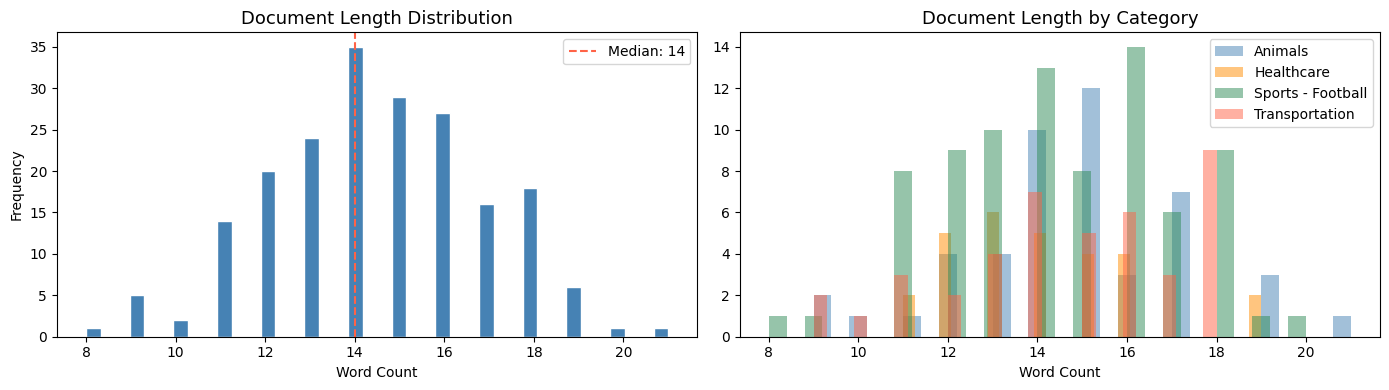

       word_count
count       199.0
mean         14.5
std           2.4
min           8.0
25%          13.0
50%          14.0
75%          16.0
max          21.0


In [360]:
# ── Document length distribution ──────────────────────────────────────────
data["word_count"] = data["title"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall histogram
axes[0].hist(data["word_count"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Document Length Distribution", fontsize=13)
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].axvline(data["word_count"].median(), color="tomato",
                linestyle="--", label=f'Median: {data["word_count"].median():.0f}')
axes[0].legend()

# By category
colors = ["steelblue", "darkorange", "seagreen", "tomato"]
for i, (cat, grp) in enumerate(data.groupby("topic")):
    axes[1].hist(grp["word_count"], bins=30, alpha=0.5, label=cat, color=colors[i])
axes[1].set_title("Document Length by Category", fontsize=13)
axes[1].set_xlabel("Word Count")
axes[1].legend()

plt.tight_layout()
plt.show()

print(data[["word_count"]].describe().round(1))

Remove Stop Words

In [361]:
# !pip install scikit-learn nltk gensim numpy pandas

# Try to load NLTK stopwords; fall back to a small built-in list if download fails
try:
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    STOP_WORDS = set(stopwords.words('english'))
except Exception:
    STOP_WORDS = {'a','an','the','and','or','but','if','of','at','by','for','with',
                  'about','to','from','in','on','is','are','was','were','be','been',
                  
                  'being','have','has','had','do','does','did','this','that','these',
                  'those','i','you','he','she','it','we','they','them','their','our',
                  'my','your','his','her','its'}

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

stop_words = STOP_WORDS
print(f'Using {len(stop_words)} English stop words.')

# remove non-english words that appear in data
# included also due to frequency
extra_words = {'also', 'περὶ', 'σπέρμα', 'τηθύς',
               'τραχεῖα', 'φυτά', 'φυτόν',
                'φυτῶν', 'המלח', 'ים', 'מעבדות', 'פרמייר', 
                'ἀγγεῖον', 'ἀρτηρία', 'ストーンオーシャン',
                '達爾膚生醫科技', '대우조선해양', '빅오션', '케이뷰티','한화오션',
                "list", "lists", "smith", "hope", "Lists", "of", "List"
}

stop_words.update(extra_words)
print(f'Using {len(stop_words)} English stop words.')

stop_words.remove('σπέρμα')
print(f'Using {len(stop_words)} English stop words.')

Using 198 English stop words.
Using 224 English stop words.
Using 223 English stop words.


In [362]:
stop_words

{'List',
 'Lists',
 'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'hope',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'list',
 'lists',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 

In [363]:
tokenizer = CountVectorizer().build_tokenizer()
stemmer = SnowballStemmer('english')

Pre-Process for TF-IDF

In [364]:
def preprocess(text):
    tokens = tokenizer(text)  # tokenize
    tokens = [stemmer.stem(t) for t in tokens] # stem
    tokens = [t for t in tokens if t not in stop_words]  # drop stop words
    return tokens

processed = [preprocess(d) for d in title]
for i, p in enumerate(processed, 1):
    print(f'Article{i}: {p}')

Article1: ['termin', 'ill', 'connecticut', 'woman', 'end', 'life', 'term', 'vermont']
Article2: ['king', 'charl', 'iii', 'prostat', 'oper', 'next', 'week', 'kate', 'recov', 'abdomin', 'surgeri']
Article3: ['communiti', 'health', 'center', 'serv', '11', 'american', 'safeti', 'net', 'stress']
Article4: ['washington', 'state', 'reach', 'near', '150', 'million', 'settlement', 'johnson', 'johnson', 'opioid', 'crisi']
Article5: ['communiti', 'health', 'center', 'serv', '11', 'american', 'safeti', 'net', 'stress']
Article6: ['defens', 'secretari', 'lloyd', 'austin', 'return', 'work', 'pentagon', 'cancer', 'surgeri', 'complic']
Article7: ['maker', 'recal', 'sleep', 'apnea', 'machin', 'agre', 'halt', 'sale', 'us']
Article8: ['real', 'news', 'look', 'happen', 'week']
Article9: ['austin', 'kept', 'prostat', 'cancer', 'surgeri', 'complic', 'secret', 'everyon', 'even', 'biden']
Article10: ['biden', 'say', 'austin', 'still', 'confid', 'reveal', 'hospit', 'laps', 'judgment']
Article11: ['suprem', 'co

In [365]:
# pass preprocess function as the tokenizer
bow_vectorizer = CountVectorizer(tokenizer=preprocess, token_pattern=None, lowercase=False)
X_bow = bow_vectorizer.fit_transform(title)
vocab = bow_vectorizer.get_feature_names_out()

print(f'Vocabulary size: {len(vocab)}')
print(f'Vocabulary: {list(vocab)}')
print(f'Matrix shape: {X_bow.shape}  (199 Articles x {len(vocab)} words)')

Vocabulary size: 904
Vocabulary: ['000', '10', '11', '12', '13', '14', '150', '17', '18', '1st', '20', '200', '2023', '2024', '21', '23', '24', '25', '27', '300', '31', '32', '34', '37', '3rd', '40', '400', '49er', '500', '53', '6th', '737', '747', '78', '9th', 'aaron', 'abdomin', 'abound', 'account', 'accus', 'achiev', 'action', 'activist', 'add', 'adjust', 'adolesc', 'advanc', 'advoc', 'afc', 'agre', 'air', 'airlin', 'airport', 'alabama', 'alaska', 'alleg', 'allen', 'allig', 'american', 'amid', 'analysi', 'andi', 'angel', 'anger', 'ani', 'anim', 'announc', 'anoth', 'antarctica', 'anti', 'antonio', 'ap', 'ape', 'apnea', 'appeal', 'appear', 'arrest', 'arthur', 'atlanta', 'attack', 'attempt', 'attend', 'attract', 'au', 'austin', 'australia', 'australian', 'averag', 'avian', 'award', 'away', 'back', 'bag', 'baker', 'baltimor', 'ban', 'basket', 'bear', 'beat', 'becaus', 'beckenbau', 'becom', 'befor', 'begin', 'behind', 'belichick', 'belief', 'bengal', 'benito', 'best', 'bet', 'beyonsleigh

In [366]:
# display the document-feature matrix as a nice table
df_bow = pd.DataFrame(
    X_bow.toarray(),
    columns=vocab,
    index=[f'Article{i}' for i in range(1, 200)]
)
df_bow

,000,10,11,12,13,14,150,17,18,1st,20,200,2023,2024,21,23,24,25,27,300,31,32,34,37,3rd,40,400,49er,500,53,6th,737,747,78,9th,aaron,abdomin,abound,account,accus,achiev,action,activist,add,adjust,adolesc,advanc,advoc,afc,agre,air,airlin,airport,alabama,alaska,alleg,allen,allig,american,amid,analysi,andi,angel,anger,ani,anim,announc,anoth,antarctica,anti,antonio,ap,ape,apnea,appeal,appear,arrest,arthur,atlanta,attack,attempt,attend,attract,au,austin,australia,australian,averag,avian,award,away,back,bag,baker,baltimor,ban,basket,bear,beat,becaus,beckenbau,becom,befor,begin,behind,belichick,belief,bengal,benito,best,bet,beyonsleigh,biden,big,biggest,bill,billion,bird,black,blast,blew,blood,blowout,boe,bolt,bomb,born,bowl,break,breakthrough,breed,brian,brightlin,britain,broader,brock,brown,buc,buccan,buffalo,built,bullfight,burn,busi,café,california,call,callahan,cam,camel,campbel,cancel,cancer,canin,capit,carbon,card,cargo,catch,caus,center,central,certain,challeng,championship,chanc,chang,channel,charg,charger,charl,charli,cheer,chicago,chief,circus,citi,climat,climb,club,coach,coast,cold,coldest,collaps,colleg,collid,collis,coloni,come,command,communic,communiti,compani,complet,complic,composit,concern,confer,confid,connecticut,continu,control,coordin,corolla,could,counti,court,coverag,cow,cowboy,crash,crisi,cross,crowd,cruel,cuddl,culprit,cup,custom,czech,dalla,dan,david,day,dazzl,dead,deboer,debt,debut,decad,decid,decis,defens,defi,degre,delay,deliv,delta,demand,demeco,derail,design,despit,detail,devast,die,dirti,disappoint,disast,disclosur,discourag,disrupt,division,doctor,dog,dolphin,domin,door,draft,drastic,draw,drift,drink,drive,driver,duo,dure,dynasti,eagl,earli,edmund,effect,efruz,egg,electron,elud,elus,embark,embrac,emerg,eminem,emperor,end,energi,engin,enjoy,enlist,enthusiast,eros,error,evacu,even,ever,everyon,excit,exempt,exit,explor,extinct,extra,eye,face,facil,failur,fair,falcon,famili,fan,farm,fatal,favorit,fed,feder,fiber,fight,fill,final,finalist,find,fine,finish,fire,firefight,first,fit,fizzl,flame,fli,flight,florida,flu,focus,follow,footbal,ford,forecast,format,found,four,fourth,francisco,franz,front,frontier,fuel,full,fuselag,futil,game,gang,gateway,gator,gavin,georgia,german,germani,get,giraff,girl,give,glimmer,go,goe,goff,good,got,gov,great,ground,group,guid,guin,halt,haneda,happen,harbaugh,hard,hat,head,health,helmet,help,herd,high,highlight,highway,hill,hippo,hire,histori,hit,hole,home,homeless,hors,hospit,host,hour,hous,human,humor,hundr,hungri,ici,iii,ill,illeg,includ,india,indiana,industri,inflight,injur,injuri,insid,inspect,interim,interst,interview,investig,island,issu,jack,jackson,jaguar,jan,japan,japanes,jare,jerod,jet,jetlin,jfk,jim,job,john,johnson,join,joke,jordan,josh,jr,judgment,jurgen,kalen,kate,kelc,kennel,kenya,kept,key,kid,kill,kind,king,klopp,kneel,know,known,korea,lack,lake,land,landmark,laps,larg,largest,las,latest,law,lead,leadership,leav,led,leg,let,lie,life,light,like,limb,lion,littl,live,liverpool,lloyd,local,lock,longest,look,loos,los,lose,loss,love,machin,made,mahom,major,make,maker,male,man,mandatori,market,marshland,match,mate,materi,matrix,matthew,max,mayb,mayo,mcafe,mccaffrey,mccarthi,mccormick,mean,meant,meat,medic,meet,messag,mexico,miami,michael,michigan,midair,mike,mileston,million,minnesota,minor,minus,miss,model,moment,monkey,montana,moor,morri,mother,move,must,mvp,name,nation,natur,ncaa,near,neglig,neighborhood,net,never,new,newest,news,newsom,next,nfc,nfl,nick,nobodi,northeast,nose,ntsb,number,offens,offer,offic,offici,often,oh,oklahoma,old,oldest,onc,one,open,oper,opioid,order,ot,otter,outbreak,outsid,overpow,owner,ownership,packer,panel,panther,park,part,partnership,pass,passeng,pat,patrick,patriot,paw,pay,paywal,peacock,penguin,penix,pentagon,peopl,peru,philadelphia,philli,photo,photoshoot,pick,piec,pierc,pig,pilot,place,plan,plane,play,player,playoff,plot,point,poland,poll,portugues,possibl,poultri,prepar,prescott,presid,previous,price,pro,product,project,promot,propo

In [367]:
# cosine similarity on BOW vectors
sim_bow = cosine_similarity(X_bow)

df_sim_bow = pd.DataFrame(
    sim_bow.round(3),
    columns=[f'Article{i}' for i in range(1, 200)],
    index=[f'Article{i}' for i in range(1, 200)]
)
df_sim_bow

,Article1,Article2,Article3,Article4,Article5,Article6,Article7,Article8,Article9,Article10,Article11,Article12,Article13,Article14,Article15,Article16,Article17,Article18,Article19,Article20,Article21,Article22,Article23,Article24,Article25,Article26,Article27,Article28,Article29,Article30,Article31,Article32,Article33,Article34,Article35,Article36,Article37,Article38,Article39,Article40,Article41,Article42,Article43,Article44,Article45,Article46,Article47,Article48,Article49,Article50,Article51,Article52,Article53,Article54,Article55,Article56,Article57,Article58,Article59,Article60,Article61,Article62,Article63,Article64,Article65,Article66,Article67,Article68,Article69,Article70,Article71,Article72,Article73,Article74,Article75,Article76,Article77,Article78,Article79,Article80,Article81,Article82,Article83,Article84,Article85,Article86,Article87,Article88,Article89,Article90,Article91,Article92,Article93,Article94,Article95,Article96,Article97,Article98,Article99,Article100,Article101,Article102,Article103,Article104,Article105,Article106,Article107,Article108,Article109,Article110,Article111,Article112,Article113,Article114,Article115,Article116,Article117,Article118,Article119,Article120,Article121,Article122,Article123,Article124,Article125,Article126,Article127,Article128,Article129,Article130,Article131,Article132,Article133,Article134,Article135,Article136,Article137,Article138,Article139,Article140,Article141,Article142,Article143,Article144,Article145,Article146,Article147,Article148,Article149,Article150,Article151,Article152,Article153,Article154,Article155,Article156,Article157,Article158,Article159,Article160,Article161,Article162,Article163,Article164,Article165,Article166,Article167,Article168,Article169,Article170,Article171,Article172,Article173,Article174,Article175,Article176,Article177,Article178,Article179,Article180,Article181,Article182,Article183,Article184,Article185,Article186,Article187,Article188,Article189,Article190,Article191,Article192,Article193,Article194,Article195,Article196,Article197,Article198,Article199
Article1,1.0,0.0,0.0,0.0,0.0,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,1.0,0.0,0.0,0.000,0.000,0.0,0.000,1.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.107,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.112,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.112,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.000,0.000,0.000,0.0
Article2,0.0,1.0,0.0,0.0,0.0,0.095,0.0,0.135,0.191,0.0,0.0,0.0,0.0,0.0,0.135,0.191,0.0,0.0,0.0,0.0,0.0,0.000,0.201,1.0,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.087,0.0,0.000,0.0,0.095,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.095,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.095,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.0,0.091,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.000,0.000,0.000,0.0
Article3,0.0,0.0,1.0,0.0,1.0,0.000,0.0,0.000,0

Cleaning for Embedding Data

In [368]:
def clean_text(text: str) -> str:
    """Light cleaning for news text."""
    # Decode HTML entities
    text = text.replace("&lt;", "<").replace("&gt;", ">").replace("&amp;", "&")
    text = text.replace("&quot;", '"').replace("&#39;", "'")
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)
    # Collapse multiple spaces / newlines
    text = re.sub(r"\s+", " ", text).strip()
    # Remove Punctuation
    # text = re.sub(r"[^\w\s]", "", text)
    return text

data["clean_text"] = data["title"].apply(clean_text)

# Drop very short documents
before = len(data)
data = data[data["clean_text"].str.split().str.len() >= 1].reset_index(drop=True)
print(f"Dropped {before - len(data)} too-short documents. Remaining: {len(data):,}")

# The list of strings we'll feed to BERTopic
docs = data["clean_text"].tolist()
print(f"\n✅ Ready: {len(docs):,} documents")

print(docs[:5])

Dropped 0 too-short documents. Remaining: 199

✅ Ready: 199 documents
['Terminally ill Connecticut woman ends her life on her own terms, in Vermont', 'King Charles III will have a prostate operation next week while Kate recovers from abdominal surgery', "Community health centers serve 1 in 11 Americans. They're a safety net under stress", 'Washington state reaches a nearly $150 million settlement with Johnson & Johnson over opioid crisis', "Community health centers serve 1 in 11 Americans. They're a safety net under stress"]


TF-IDF

In [369]:
tfidf_vectorizer = TfidfVectorizer(tokenizer=preprocess, token_pattern=None, lowercase=False)
X_tfidf = tfidf_vectorizer.fit_transform(title) # used for randomforest

df_tfidf = pd.DataFrame(
    X_tfidf.toarray().round(3),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=[f'Article {i}' for i in range(1, 200)]
)
df_tfidf

,000,10,11,12,13,14,150,17,18,1st,20,200,2023,2024,21,23,24,25,27,300,31,32,34,37,3rd,40,400,49er,500,53,6th,737,747,78,9th,aaron,abdomin,abound,account,accus,achiev,action,activist,add,adjust,adolesc,advanc,advoc,afc,agre,air,airlin,airport,alabama,alaska,alleg,allen,allig,american,amid,analysi,andi,angel,anger,ani,anim,announc,anoth,antarctica,anti,antonio,ap,ape,apnea,appeal,appear,arrest,arthur,atlanta,attack,attempt,attend,attract,au,austin,australia,australian,averag,avian,award,away,back,bag,baker,baltimor,ban,basket,bear,beat,becaus,beckenbau,becom,befor,begin,behind,belichick,belief,bengal,benito,best,bet,beyonsleigh,biden,big,biggest,bill,billion,bird,black,blast,blew,blood,blowout,boe,bolt,bomb,born,bowl,break,breakthrough,breed,brian,brightlin,britain,broader,brock,brown,buc,buccan,buffalo,built,bullfight,burn,busi,café,california,call,callahan,cam,camel,campbel,cancel,cancer,canin,capit,carbon,card,cargo,catch,caus,center,central,certain,challeng,championship,chanc,chang,channel,charg,charger,charl,charli,cheer,chicago,chief,circus,citi,climat,climb,club,coach,coast,cold,coldest,collaps,colleg,collid,collis,coloni,come,command,communic,communiti,compani,complet,complic,composit,concern,confer,confid,connecticut,continu,control,coordin,corolla,could,counti,court,coverag,cow,cowboy,crash,crisi,cross,crowd,cruel,cuddl,culprit,cup,custom,czech,dalla,dan,david,day,dazzl,dead,deboer,debt,debut,decad,decid,decis,defens,defi,degre,delay,deliv,delta,demand,demeco,derail,design,despit,detail,devast,die,dirti,disappoint,disast,disclosur,discourag,disrupt,division,doctor,dog,dolphin,domin,door,draft,drastic,draw,drift,drink,drive,driver,duo,dure,dynasti,eagl,earli,edmund,effect,efruz,egg,electron,elud,elus,embark,embrac,emerg,eminem,emperor,end,energi,engin,enjoy,enlist,enthusiast,eros,error,evacu,even,ever,everyon,excit,exempt,exit,explor,extinct,extra,eye,face,facil,failur,fair,falcon,famili,fan,farm,fatal,favorit,fed,feder,fiber,fight,fill,final,finalist,find,fine,finish,fire,firefight,first,fit,fizzl,flame,fli,flight,florida,flu,focus,follow,footbal,ford,forecast,format,found,four,fourth,francisco,franz,front,frontier,fuel,full,fuselag,futil,game,gang,gateway,gator,gavin,georgia,german,germani,get,giraff,girl,give,glimmer,go,goe,goff,good,got,gov,great,ground,group,guid,guin,halt,haneda,happen,harbaugh,hard,hat,head,health,helmet,help,herd,high,highlight,highway,hill,hippo,hire,histori,hit,hole,home,homeless,hors,hospit,host,hour,hous,human,humor,hundr,hungri,ici,iii,ill,illeg,includ,india,indiana,industri,inflight,injur,injuri,insid,inspect,interim,interst,interview,investig,island,issu,jack,jackson,jaguar,jan,japan,japanes,jare,jerod,jet,jetlin,jfk,jim,job,john,johnson,join,joke,jordan,josh,jr,judgment,jurgen,kalen,kate,kelc,kennel,kenya,kept,key,kid,kill,kind,king,klopp,kneel,know,known,korea,lack,lake,land,landmark,laps,larg,largest,las,latest,law,lead,leadership,leav,led,leg,let,lie,life,light,like,limb,lion,littl,live,liverpool,lloyd,local,lock,longest,look,loos,los,lose,loss,love,machin,made,mahom,major,make,maker,male,man,mandatori,market,marshland,match,mate,materi,matrix,matthew,max,mayb,mayo,mcafe,mccaffrey,mccarthi,mccormick,mean,meant,meat,medic,meet,messag,mexico,miami,michael,michigan,midair,mike,mileston,million,minnesota,minor,minus,miss,model,moment,monkey,montana,moor,morri,mother,move,must,mvp,name,nation,natur,ncaa,near,neglig,neighborhood,net,never,new,newest,news,newsom,next,nfc,nfl,nick,nobodi,northeast,nose,ntsb,number,offens,offer,offic,offici,often,oh,oklahoma,old,oldest,onc,one,open,oper,opioid,order,ot,otter,outbreak,outsid,overpow,owner,ownership,packer,panel,panther,park,part,partnership,pass,passeng,pat,patrick,patriot,paw,pay,paywal,peacock,penguin,penix,pentagon,peopl,peru,philadelphia,philli,photo,photoshoot,pick,piec,pierc,pig,pilot,place,plan,plane,play,player,playoff,plot,point,poland,poll,portugues,possibl,poultri,prepar,prescott,presid,previous,price,pro,product,project,promot,propo

Embedding

In [370]:
# method b
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [371]:
print("Generating embeddings...")
embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)

print(f"\n✅ Embeddings shape: {embeddings.shape}")
print(f"   → {embeddings.shape[0]} documents × {embeddings.shape[1]} dimensions")

Generating embeddings...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


✅ Embeddings shape: (199, 384)
   → 199 documents × 384 dimensions


Split Data

In [372]:
X_tf = X_tfidf
y = topic

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tf, y, test_size=0.2, random_state=SEED, stratify=y
)

In [373]:
X_emb = embeddings
y = topic

X_train_emd, X_test_emd, y_train_emd, y_test_emb = train_test_split(
    X_emb, y, test_size=0.2, random_state=SEED, stratify=y
)

Random Forest Classifer + K-Fold Validation

In [374]:
k = 5
# trying different parameters
n_estm = [100, 200, 300, 400, 500]
max_dpth = [2, 3, 5, 7, 9, 10, 11]

randomforest = RandomForestClassifier(random_state=SEED)

# cross val + hyperparameter tuning
models_tfidf = GridSearchCV(
    randomforest,
    param_grid=dict(n_estimators=n_estm, max_depth=max_dpth),
    cv=k,
    scoring='f1_macro',
    return_train_score=True
)

# cross val + hyperparameter tuning
models_emb = GridSearchCV(
    randomforest,
    param_grid=dict(n_estimators=n_estm, max_depth=max_dpth),
    cv=k,
    scoring='f1_macro',
    return_train_score=True
)

models_tfidf.fit(X_train_tfidf, y_train_tfidf)
models_emb.fit(X_train_emd, y_train_emd)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

Find the Best Parameters

In [375]:
# best parameters for tf-idf
best_model_tfidf = models_tfidf.best_estimator_
print(models_tfidf.best_params_)

# best parameters for embedding
best_model_emb = models_emb.best_estimator_
print(models_emb.best_params_)

{'max_depth': 10, 'n_estimators': 200}
{'max_depth': 7, 'n_estimators': 200}


TF-IDF Feature Importance

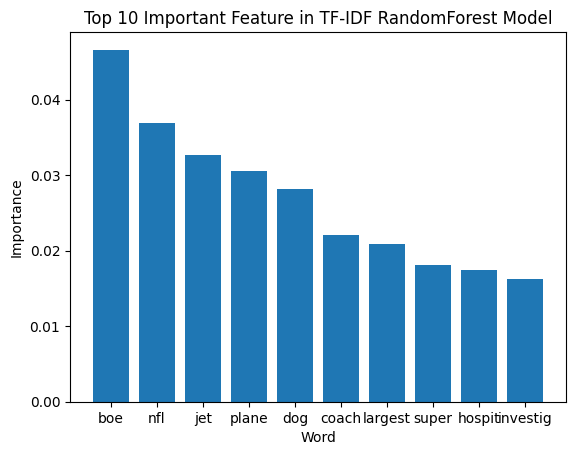

In [376]:
# extract important features
feature_names = tfidf_vectorizer.get_feature_names_out()
importance = best_model_tfidf.feature_importances_

feat_df = pd.DataFrame({
    'word': feature_names,
    'importance': importance
})

# top 10 features
top = feat_df.sort_values(
    by='importance',
    ascending=False
)

top10 = top.head(10)

# create bar char
plt.bar(top10["word"], top10["importance"])
plt.ylabel("Importance")
plt.xlabel("Word")
plt.title("Top 10 Important Feature in TF-IDF RandomForest Model")
plt.show()

TF-IDF Recall, Precision, F1

In [377]:
y_pred = best_model_tfidf.predict(X_test_tfidf)

# evaluate the model
print(classification_report(y_test_tfidf, y_pred))

                   precision    recall  f1-score   support

          Animals       1.00      0.30      0.46        10
       Healthcare       1.00      0.50      0.67         6
Sports - Football       0.57      1.00      0.73        16
   Transportation       1.00      0.75      0.86         8

         accuracy                           0.70        40
        macro avg       0.89      0.64      0.68        40
     weighted avg       0.83      0.70      0.68        40



Embedding Recall, Precision, F1

In [378]:
y_pred = best_model_emb.predict(X_test_emd)

# evaluate the model
print(classification_report(y_test_emb, y_pred))

                   precision    recall  f1-score   support

          Animals       1.00      0.80      0.89        10
       Healthcare       1.00      0.83      0.91         6
Sports - Football       0.89      1.00      0.94        16
   Transportation       0.89      1.00      0.94         8

         accuracy                           0.93        40
        macro avg       0.94      0.91      0.92        40
     weighted avg       0.93      0.93      0.92        40



Feature Selection

In [ ]:
# extract important features
feature_names = tfidf_vectorizer.get_feature_names_out()
importance = best_model_tfidf.feature_importances_

feat_df = pd.DataFrame({
    'word': feature_names,
    'importance': importance
})

# top features
top = feat_df.sort_values(
    by='importance',
    ascending=False
)

# select top N features (top 150)
top_features_index = top.head(150).index
X_train_selected = X_train_tfidf[:, top_features_index]
X_test_selected = X_test_tfidf[:, top_features_index]

In [388]:
# train the RandomForest model with selected features & experimented with parameters
rf_feat = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=SEED)
rf_feat.fit(X_train_selected, y_train_tfidf)

# evaluate the model
y_pred = rf_feat.predict(X_test_selected)
print(classification_report(y_test_tfidf, y_pred))

                   precision    recall  f1-score   support

          Animals       0.83      0.50      0.62        10
       Healthcare       1.00      0.67      0.80         6
Sports - Football       0.70      1.00      0.82        16
   Transportation       1.00      0.88      0.93         8

         accuracy                           0.80        40
        macro avg       0.88      0.76      0.79        40
     weighted avg       0.84      0.80      0.79        40

